# Stochastic linearization for viscous drag effects
In this example, the curved floating bridge created in the model creation examples is exposed to wave excitation and viscous quadratic drag damping is included using stochastic linearization. This implies that the response prediction is run in an iterative manner where the response is used as a basis to estimate the linearized damping.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from wawi.model import Model, Windstate, Seastate
from wawi.io import import_folder

## Import of WAWI-model
First, the model of the simple curved floating bridge (defined in the model generation examples) is imported. Thereafter, the number of dry modes is defined together with the frequency axes of the FRF (`omega`) of the combined system and the aerodynamics (`omega_aero`).

In [2]:
# Import model
model = Model.from_wwi('./input/model_curved.wwi')
model.n_modes = 50      # define number of dry modes

# Define omega for FRF of system and aerodynamics
omega = np.arange(0.001, 2, 0.005)
omega_hydro = np.arange(0.001, 2, 0.05)

Using the folder import (JSON-files), with a 'pontoon_types.json' file as follows would provide drag damping values relevant for our problem:

```json
{
    "*": {
        "Cd": [1.0, 1.0, 2.0],
        "area": [100.0, 200.0, 200.0]
    }

}
```

Here, the file specifies a drag coefficient Cd=1.0 for motion in local x and y directions of all pontoons, and Cd=2.0 for motion in z-direction of all pontoons. Corresponding areas are 100.0 $m^2$ (x), 200.0 $m^2$ (y) and 200.0 $m^2$ (z). These values are defined in the 'pontoon_types.json' file, or by specifying the values directly for the corresponding attributes in the `PontoonType` object (either during initiation or by modifying the object directly). If different coefficients are wanted for different pontoon types, these can be specified by separately. In the example the wildcard key '*' is used in the json-file, but the names of the pontoon types can be used instead. Default values are Cd=0.0.

Also, drag elements (representing mooring lines) can be defined, to accomodate the possibility for floating bridges to have mooring lines with significant quadratic drag damping. Then the relevant elements need to be included in the element definition. Note that this, as for the drag of the pontoons, is only solved in a linearized sense using (approximate) stochastic linearization techniques. The `drag_elements.json` file defines the relevant elements, and is defined as follows:

```json
{
    "mooring_wire":
        {   "sections": "MooringWire",
            "zrange": [-1e4, 0.0],
            "rho": 1025.0,
            "Cd": [0.1, 1.2, 1.2],
            "D": 0.146}
}
```

For the drag element group named "mooring_wire" above, all elements present in the elements assigned with the relevant section assignment(s) in `element.json` (either list of several strings or single string defined with property `sections`) and that have a z-coordinate inside the provided `zrange` will be given quadratic drag damping according to the specified density (`rho`), drag coefficients in local x, y and z-direction (`Cd`) and diameter (`D`). 

Drag elements are not included in the example, for simplicity.

For simplicity, in this example, we instead rely on modification of the WAWI model object directly to add drag damping:

In [3]:
model.hydro.pontoon_types[0].Cd = [1.0, 1.0, 2.0]
model.hydro.pontoon_types[0].area = [100.0, 200.0, 200.0]

model.aero = None # remove aerodynamic definitions in model for convenience

## Defining `Seastate`
The sea state is defined either directly from initiation of the `Seastate` object or by importing a json file. The resulting `seastate` object is thereafter assigned to the model using the `assign_seastate` method.

In [4]:
# Define Seastate  (JONSWAP 1d wave spectrum and cos2s distribution)
Hs = 0.4
Tp = 14.0
gamma = 6.0
s = 50.0
theta0 = 80.0
seastate = Seastate(Tp, Hs, gamma, theta0, s)

# Apply seastate to model
model.assign_seastate(seastate)

## Plotting model and relevant states
Thereafter, the model and the assigned environmental states are plotted. This relies on the plotting environment used in the BEEF Python package (more details of relevant keywords can be found there).

In [5]:
# Plot model
model.plot()

Widget(value='<iframe src="http://localhost:51612/index.html?ui=P_0x27c0b5f6f90_0&reconnect=auto" class="pyvis…

## Response prediction
Two models are created to enable quantification of the effects of the linearized quadratic drag. To include the quadratic drag damping in the analysis the parameter `include_selfexcited` is set to `['hydro', 'drag_pontoons']` (you can also add `'aero'` and `'drag_elements'` here if this is wanted) and `drag_iterations=5` (should be verified for specific case with convergence study). The response prediction for the model including the drag is run in an iterative manner where the response from each iteration is used as a basis to estimated linearized damping contributions (based on stochastic response).

In [6]:
# Since both models use the same excitation it is precomputed before copying
model.precompute_waveaction(omega_hydro)

# With quadratic pontoon drag
model_drag = model.copy() #create copy of the model object
model_drag.run_freqsim(omega, print_progress=True, include_selfexcited=['hydro', 'drag_pontoons'], drag_iterations=5)
resp_std_drag = model_drag.get_result_std(key='girder_forces')          # standard deviation

# Without quadratic pontoon drag
model.run_freqsim(omega, print_progress=False, include_selfexcited=['hydro'])
resp_std_nodrag = model.get_result_std(key='girder_forces')          # standard deviation

[ ==================== ] 100% DRAG LINEARIZATION - RUNNING ITERATION 5
 STOPPING ITERATION. Linearized damping converged by assertion with specified tolerance criterion.


In the following code cell, the standard deviations of selected moments and forces along the girder are plotted (with and without linearized drag effects):

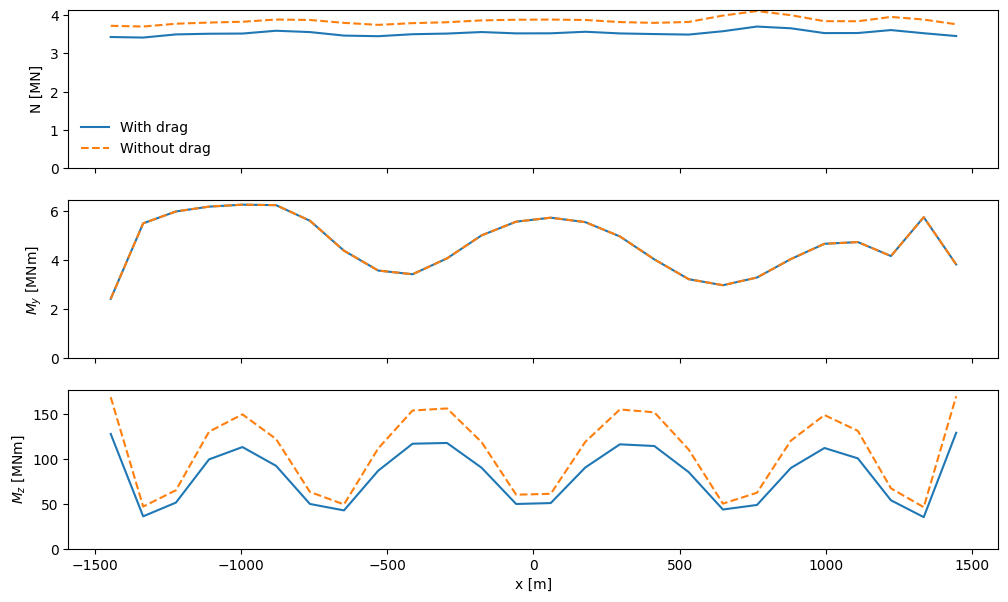

In [7]:
# Plot standard deviations
legend_ax = []
comps = {'N [MN]':0, '$M_y$ [MNm]':4, '$M_z$ [MNm]':5}
arclength_girder_force = np.array(model.modal_dry.phi_x['girder_forces'])[:, 0]

fig,ax = plt.subplots(nrows=len(comps), sharex=True, figsize=[12,7])
if np.ndim(ax)==0:
    ax = [ax]

for ix, comp in enumerate(comps):
    comp_ix = comps[comp]
    ax[ix].set_ylabel(comp)
    ax[ix].plot(arclength_girder_force, resp_std_drag[comp_ix::6]/1e6, label='With drag')
    ax[ix].plot(arclength_girder_force, resp_std_nodrag[comp_ix::6]/1e6, label='Without drag', linestyle='--')
    ax[ix].set_ylim(bottom=0)

ax[0].legend(frameon=False)
    
ax[-1].set_xlabel('x [m]');

## Modal analysis
Furthermore, we can use the linearized drag results in iterative modal analysis, as follows (modal properties relevant for current stochastic response):

In [8]:
model_drag.run_eig(include=['hydro', 'drag_pontoons'], freq_kind=False)
xi_drag = model_drag.results.xi
w_drag = model_drag.results.wn

model.run_eig(include=['hydro'])
xi_nodrag = model.results.xi
wn_nodrag = model.results.wn

[ >>>>>>>>>>>>>>>>>>>> ] 100% finished with iterative modal analysis. 
[ >>>>>>>>>>>>>>>>>>>> ] 100% finished with iterative modal analysis. 


The resulting modal damping ratios are plotted below:

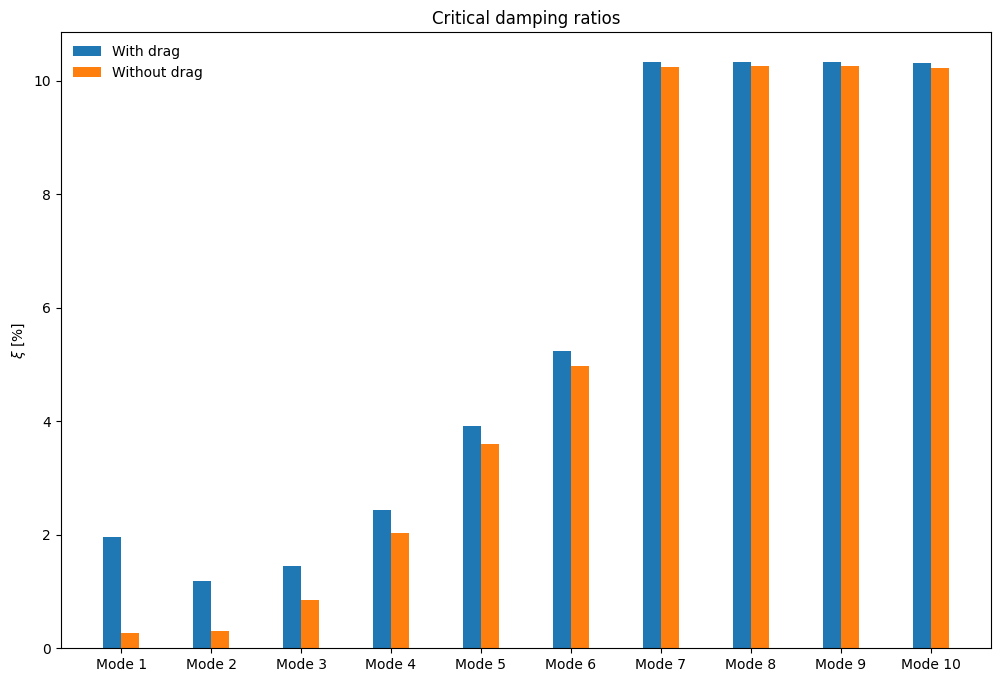

In [18]:
mode_ixs = np.arange(0,10)
cats = [f'Mode {mode_ix+1}' for mode_ix in np.array(mode_ixs)]  # categories

# Bar width and x locations
w, x = 0.2, np.arange(len(cats))

fig, ax = plt.subplots(figsize=(12,8))
ax.bar(x - w/2, 100*xi_drag[mode_ixs], width=w, label='With drag')
ax.bar(x + w/2, 100*xi_nodrag[mode_ixs], width=w, label='Without drag')

ax.set_xticks(x)
ax.set_xticklabels(cats)
ax.set_ylabel('$\\xi$ [%]')
ax.legend(frameon=False)
ax.set_title('Critical damping ratios')
plt.show()